In [74]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import scienceplots
sys.path.insert(0, r'Z:\Users\Gregory\Ca40_multi_photon')
sys.path.insert(0, r'Z:\Users\Gregory\Ca40_multi_photon\raman_simulation')
import useful_funcs
import simulation as s
from matplotlib.colors import TwoSlopeNorm
import scienceplots
import matplotlib.colors as colors
import matplotlib.ticker as ticker

cb_d = (106/255, 139/255,239/255)
cb_l = (158/255, 190/255,255/255)
cr_d = (214/255, 82/255,68/255)
cr_l = (244/255, 152/255,122/255)

In [2]:
sim = s.sim()
sim.ls_order = 8
sim.get_f()

In [3]:
sim.ls_order

8

In [65]:
def f2(b_sp, b_pi):
    Pb_bank = np.array([.180])
    sim.Pr = 0
    sim.b_sp = b_sp
    sim.b_pi = b_pi
    sim.get_rabi_frequencies()
    sim.analytics(Pb_bank)
    w2 = (sim.δ02_bank - sim.δ12_bank)
    w4 = (sim.δ02_bank - sim.δ12_bank + sim.δ04_bank - sim.δ14_bank)
    w6 = (sim.δ02_bank - sim.δ12_bank + sim.δ04_bank - sim.δ14_bank+ sim.δ06_bank - sim.δ16_bank)
    w8 = (sim.δ02_bank - sim.δ12_bank + sim.δ04_bank - sim.δ14_bank+ sim.δ06_bank - sim.δ16_bank+ sim.δ08_bank - sim.δ18_bank)
    return w2[0], w4[0], w6[0], w8[0]

In [66]:
b_sp = np.linspace(.33, .34, 100)
b_pi = np.linspace(.325, .335, 100)

t2 = np.zeros((len(b_pi), len(b_sp)))
t4 = np.zeros((len(b_pi), len(b_sp)))
t6 = np.zeros((len(b_pi), len(b_sp)))
t8 = np.zeros((len(b_pi), len(b_sp)))

# Fill in t using a for loop
for i, y in enumerate(b_pi):
    for j, x in enumerate(b_sp):
        w2, w4, w6, w8 = f2(x, y)
        t2[i, j] = w2
        t4[i, j] = w4
        t6[i, j] = w6
        t8[i, j] = w8

In [69]:
def get_contour(val):

    contour_value = val
    all_lines = []

    for level, collection in zip(contours.levels, contours.collections):
        if np.isclose(level, contour_value):
            paths = collection.get_paths()
            for path in paths:
                coords = path.vertices
                x_coords = coords[:, 0]
                y_coords = coords[:, 1]
                all_lines.append((x_coords, y_coords))
    x1, x2 = x_coords[20], x_coords[-20]   
    y1, y2 = y_coords[20], y_coords[-20]    
    
    m = (y2 - y1)/(x2- x1)
    b = y1 - m*x1
    
    return m*b_sp + b

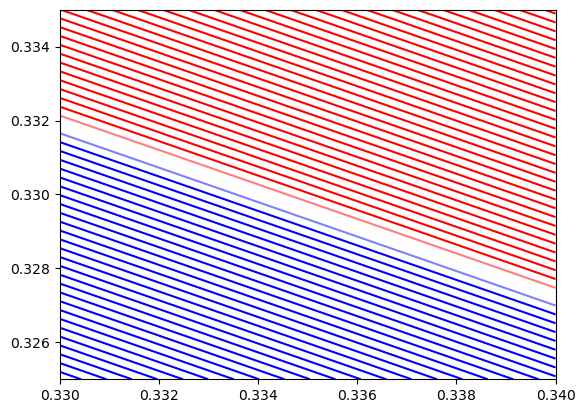

In [70]:
norm_fixed = TwoSlopeNorm(vmin=-.2, vcenter=0, vmax=.2)
levels = np.arange(-3, 4, 0.1)
contours = plt.contour(b_sp, b_pi, t8/(2*np.pi*1e3),levels=levels, cmap='bwr', norm=norm_fixed)

cp = get_contour(0.5)
indp = np.argmin(np.abs(y - cp))

c0 = get_contour(0.1)
ind0 = np.argmin(np.abs(y - c0))

cm = get_contour(-.3)
indm = np.argmin(np.abs(y - cm))

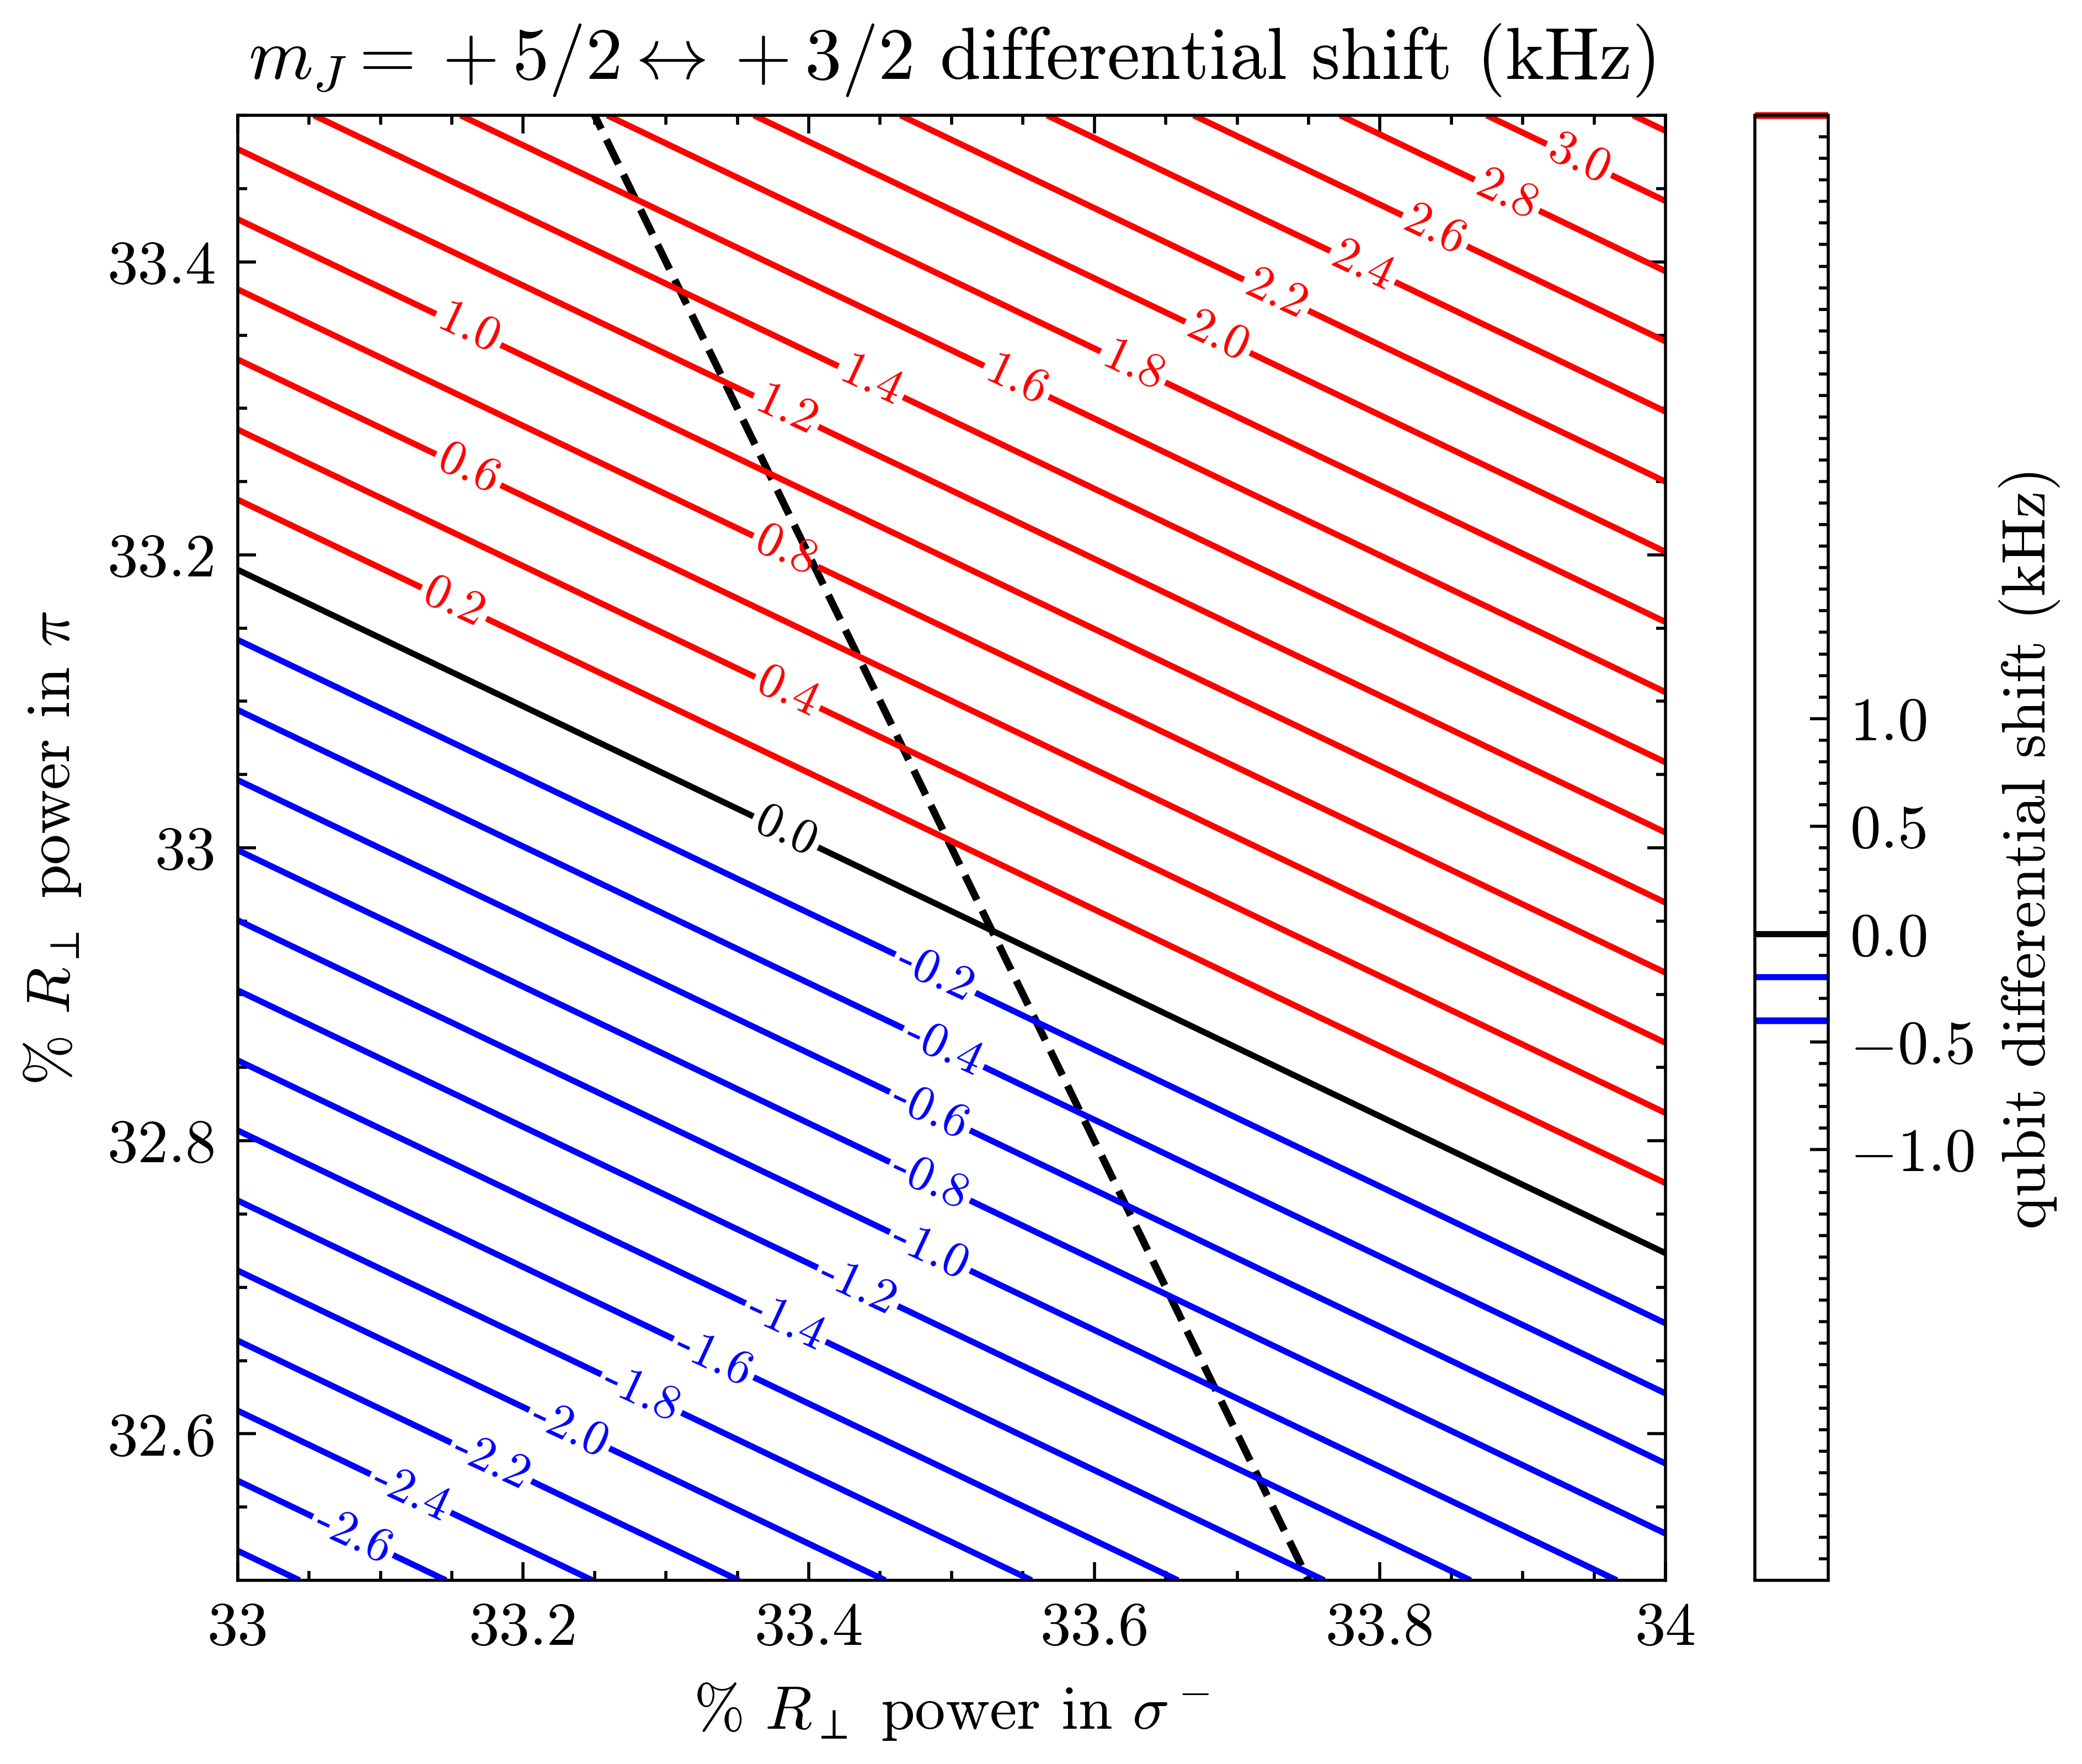

% π: 34.0% + 0.0% - 0.0%
% σ+: 33.0% + 0.0% - 0.0%


In [75]:
with plt.style.context(['science','no-latex']):
    plt.figure(figsize=(5,4), dpi = 800)
    # norm_fixed = TwoSlopeNorm(vmin=-.2, vcenter=0, vmax=.2)
    # levels = np.arange(-3, 4, 0.2)
    # contours = plt.contour(
    #     b_sp, b_pi, t8/(2*np.pi*1e3),
    #     levels=levels, cmap='bwr', norm=norm_fixed)
    
    base = plt.cm.get_cmap('bwr', 256)
    newcolors = base(np.linspace(0, 1, 256))
    mid = 128                         # center index
    newcolors[mid] = np.array([0, 0, 0, 1])   # black (RGBA)
    bwr_blackmid = colors.ListedColormap(newcolors)

    # --- Your norm ---
    norm_fixed = colors.TwoSlopeNorm(vmin=-.2, vcenter=0, vmax=.2)

    levels = np.arange(-3, 4, 0.2)

    contours = plt.contour(
        b_sp, b_pi, t8/(2*np.pi*1e3),
        levels=levels,
        cmap=bwr_blackmid,   # use the modified colormap
        norm=norm_fixed
    )

    cbar = plt.colorbar(contours, label='qubit differential shift (kHz)')
    cbar.set_ticks(np.linspace(-1, 1, 5))
    plt.clabel(contours, inline=True, fontsize=8, fmt="%.1f")
    plt.xlabel(r'% $R_\perp$ power in $\sigma^-$')
    plt.ylabel(r'% $R_\perp$ power in $\pi$')
    #plt.scatter([1/3], [1/3], marker='d', color='black', zorder=5)
    y = 1 - 2*b_sp
    plt.plot(b_sp, y, color='black', linewidth=1.2, zorder=-1, linestyle = '--')
    # plt.xlim(0.333, 0.337)
    plt.ylim(0.325, 0.335)
    plt.xlim(.33,.34)

    #plt.scatter(b_sp[indp], y[indp], color = 'darkred', zorder = 3)
    plt.scatter(b_sp[ind0], y[ind0], s = 50, zorder = 30, facecolor = 'white', edgecolor = 'black', linewidths = 2)
    #plt.scatter(b_sp[indm], y[indm], color = 'darkred', zorder = 3)
    plt.plot([b_sp[indp], b_sp[indm]], [y[indp], y[indm]], linewidth=2, color = 'black', zorder = 20)

    plt.tight_layout()

    plt.title(r'$m_J = +5/2 \leftrightarrow +3/2$ differential shift (kHz)')
    plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"{x*100:g}"))
    plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, pos: f"{y*100:g}"))




    plt.show()

    print("% π: " + str(round(y[ind0]*100, 2)) + '% + ' + str(round((y[indp] - y[ind0])*100, 2))+ '% - ' + str(round((y[ind0] - y[indm])*100, 2)) + '%')
    print("% σ+: " + str(round(b_sp[ind0]*100, 2)) + '% + ' + str(round((b_sp[indm] - b_sp[ind0])*100, 2))+ '% - ' + str(round((b_sp[ind0] - b_sp[indp])*100, 2)) + '%')


In [76]:
def f2(b_sp, b_pi, w0b):
    Pb_bank = np.array([.180])
    sim.Pr = 0
    sim.b_sp = b_sp
    sim.b_pi = b_pi
    sim.w0b = w0b
    sim.get_rabi_frequencies()
    sim.analytics(Pb_bank)
    w2 = (sim.δ02_bank - sim.δ12_bank)
    w4 = (sim.δ02_bank - sim.δ12_bank + sim.δ04_bank - sim.δ14_bank)
    w6 = (sim.δ02_bank - sim.δ12_bank + sim.δ04_bank - sim.δ14_bank+ sim.δ06_bank - sim.δ16_bank)
    w8 = (sim.δ02_bank - sim.δ12_bank + sim.δ04_bank - sim.δ14_bank+ sim.δ06_bank - sim.δ16_bank+ sim.δ08_bank - sim.δ18_bank)
    return w2[0], w4[0], w6[0], w8[0], 

In [77]:
b_sp = np.linspace(.333, .337, 100)
b_pi = 1-2*b_sp

w0b = 30e-6

In [78]:
δ8 = np.array(())

for i in range(len(b_sp)):
    w2, w4, w6, w8 = f2(b_sp[i], b_pi[i], w0b)
    δ8 = np.append(δ8, w8/(2*np.pi*1e3))

In [79]:
indp = np.where(δ8 < .5)[0][0]
ind0 = np.where(δ8 < 0.1)[0][0]
indm = np.where(δ8 < -.3)[0][0]

In [80]:
b_spm, b_sp0, b_spp = b_sp[indm], b_sp[ind0], b_sp[indp]
b_pim, b_pi0, b_pip = b_pi[indm], b_pi[ind0], b_pi[indp]

% σ+: 33.55% + -0.05% - -0.05%
% π: 32.9% + 0.11% - 0.11%


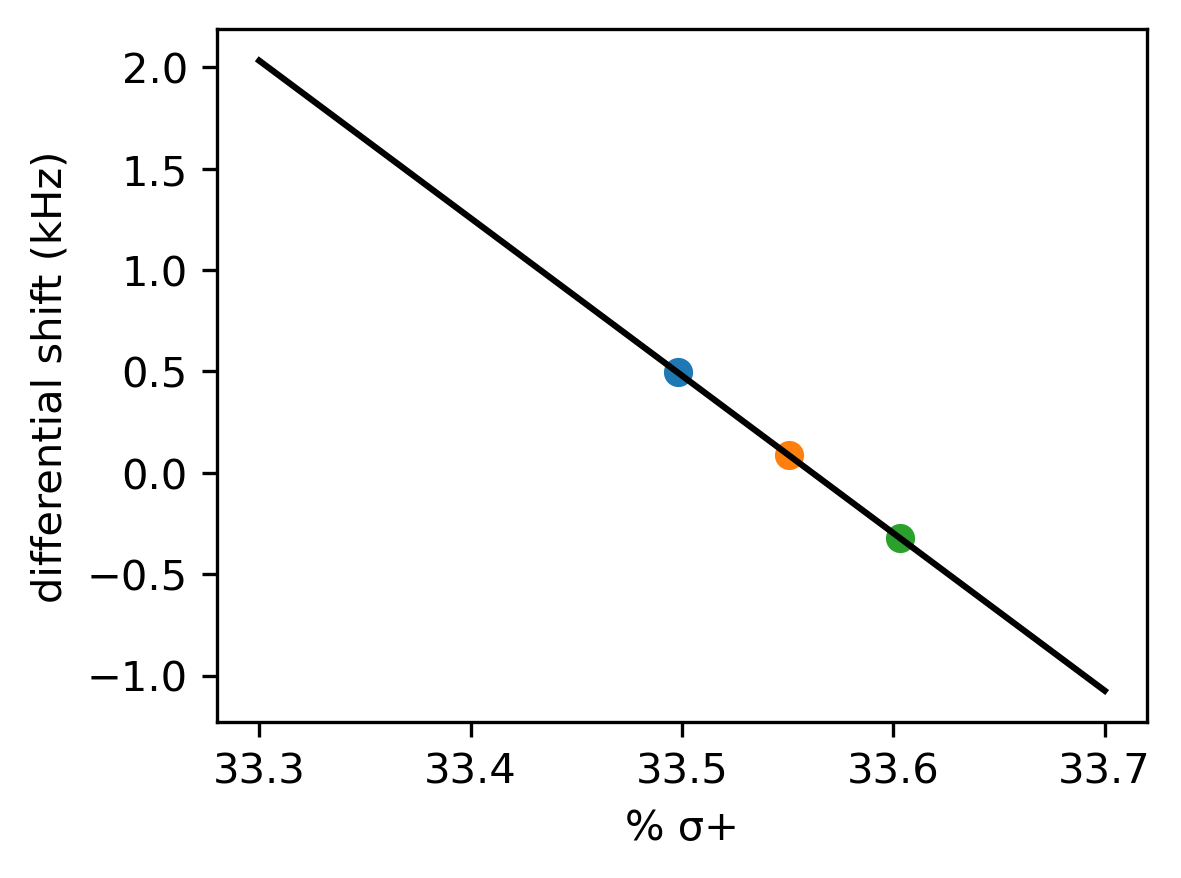

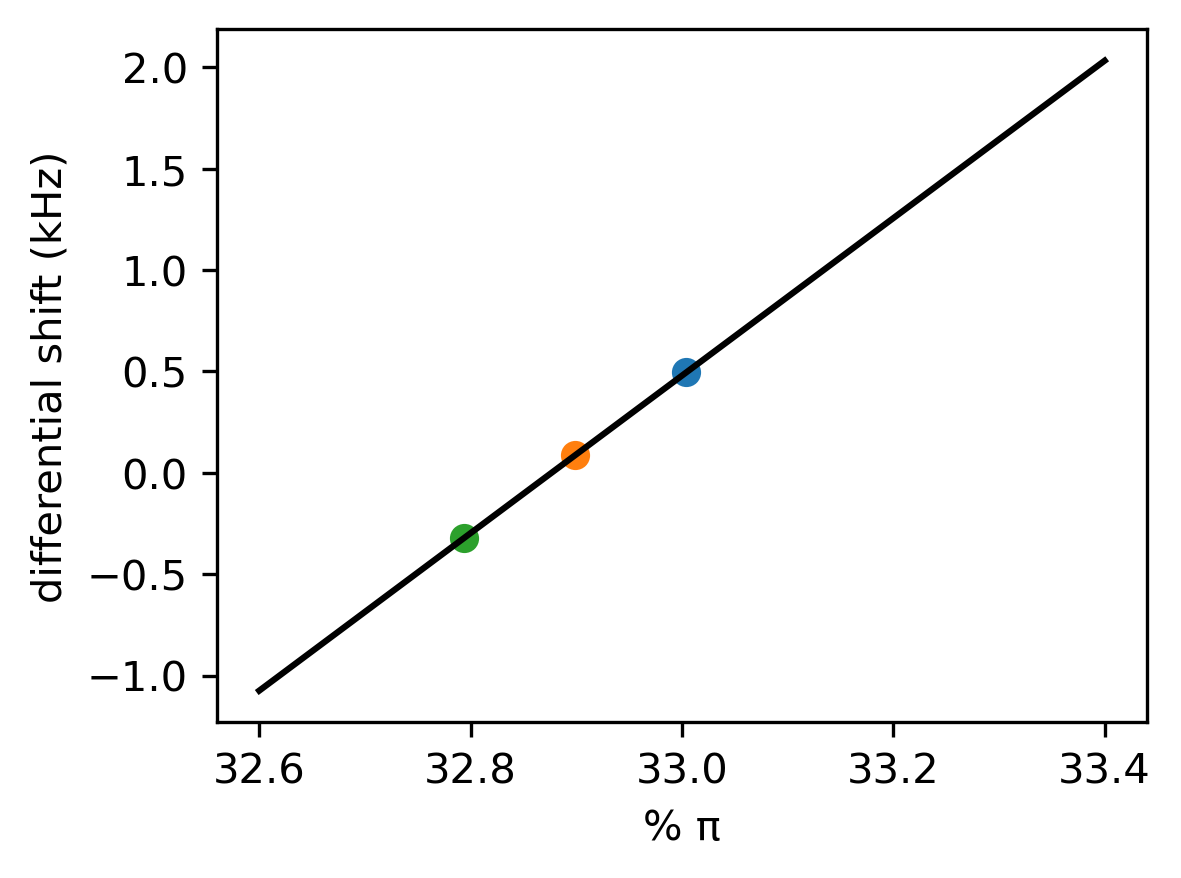

In [81]:
plt.figure(dpi = 300, figsize = (4,3))

plt.plot(b_sp*100, δ8, color = 'black')

plt.scatter(b_spp*100, δ8[indp])
plt.scatter(b_sp0*100, δ8[ind0])
plt.scatter(b_spm*100, δ8[indm])

plt.xlabel('% σ+')
plt.ylabel('differential shift (kHz)')

plt.figure(dpi = 300, figsize = (4,3))

plt.plot(b_pi*100, δ8, color = 'black')

plt.scatter(b_pip*100, δ8[indp])
plt.scatter(b_pi0*100, δ8[ind0])
plt.scatter(b_pim*100, δ8[indm])

plt.xlabel('% π')
plt.ylabel('differential shift (kHz)')

print("% σ+: " + str(round(b_sp[ind0]*100, 2)) + '% + ' + str(round((b_sp[indp] - b_sp[ind0])*100, 2))+ '% - ' + str(round((b_sp[ind0] - b_sp[indm])*100, 2)) + '%')
print("% π: " + str(round(b_pi[ind0]*100, 2)) + '% + ' + str(round((b_pi[indp] - b_pi[ind0])*100, 2))+ '% - ' + str(round((b_pi[ind0] - b_pi[indm])*100, 2)) + '%')


In [82]:
def get_polarizations(w0b):
    b_sp = np.linspace(.333, .337, 100)
    b_pi = 1-2*b_sp
    
    δ8 = np.array(())

    for i in range(len(b_sp)):
        w2, w4, w6, w8 = f2(b_sp[i], b_pi[i], w0b)
        δ8 = np.append(δ8, w8/(2*np.pi*1e3))

    indp = np.where(δ8 < .5)[0][0]
    ind0 = np.where(δ8 < 0.1)[0][0]
    indm = np.where(δ8 < -.3)[0][0]
    
    b_spm, b_sp0, b_spp = b_sp[indm], b_sp[ind0], b_sp[indp]
    b_pim, b_pi0, b_pip = b_pi[indm], b_pi[ind0], b_pi[indp]
    
    return b_sp0, b_sp0 - b_spp, b_pi0, b_pip - b_pi0

In [83]:
w0b_bank = np.linspace(27, 33, 7)*1e-6

sp_bank = np.array(())
δsp_bank = np.array(())

pi_bank = np.array(())
δpi_bank = np.array(())

for w0b in w0b_bank:
    b_sp, δb_sp, b_pi, δb_pi = get_polarizations(w0b)
    
    sp_bank = np.append(sp_bank, b_sp)
    δsp_bank = np.append(δsp_bank, δb_sp)
    
    pi_bank = np.append(pi_bank, b_pi)
    δpi_bank = np.append(δpi_bank, δb_pi)

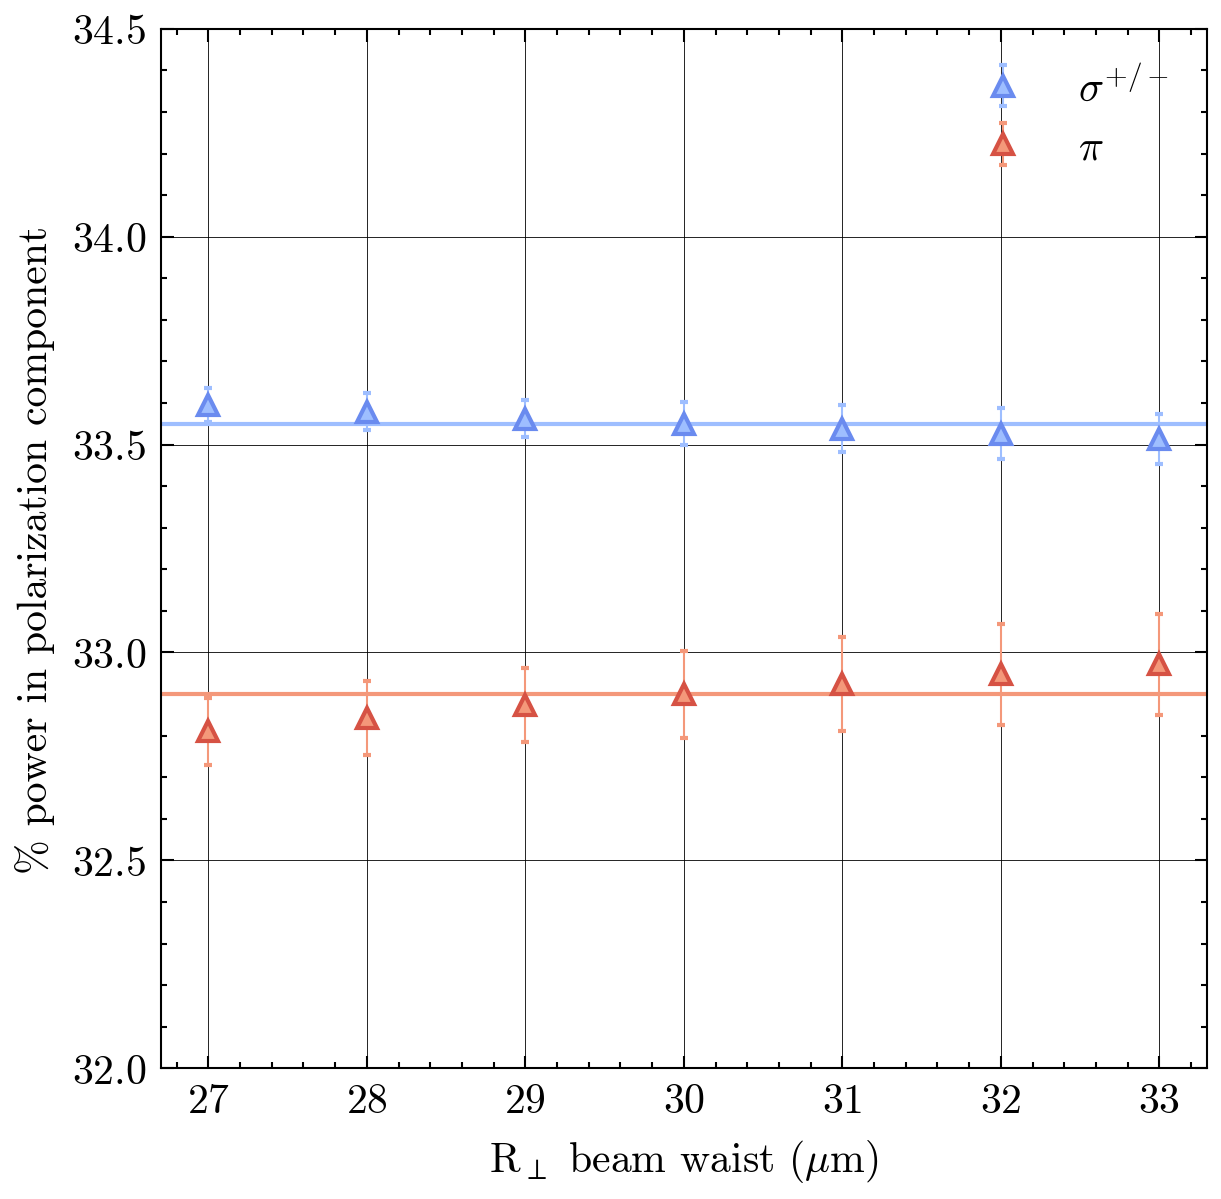

In [85]:
with plt.style.context(['science','no-latex']):
    sm_bank = 1- sp_bank - pi_bank
    δsm_bank = (δsp_bank**2 + δpi_bank**2)**.5


    plt.figure(dpi = 300, figsize = (4.5,4.5))
    plt.errorbar(w0b_bank*1e6,sp_bank*100, δsp_bank*100,marker = '^', 
                 ls = 'none', ecolor = cb_l, markeredgecolor = cb_d, 
                 markeredgewidth = 1, markersize=5, capsize=1, elinewidth = .5,
                 markerfacecolor=cb_l, label = r'$\sigma^{+/-}$')
    plt.errorbar(w0b_bank*1e6,pi_bank*100, δpi_bank*100,marker = '^',
                 ls = 'none', ecolor = cr_l, markeredgecolor = cr_d, 
                 markeredgewidth = 1, markersize=5, capsize=1, elinewidth = .5,
                 markerfacecolor=cr_l, label = r'$\pi$')
    # plt.errorbar(w0b_bank*1e6,sm_bank*100, δsm_bank*100,marker = 'd',
    #              ls = 'none', ecolor = cg_l, markeredgecolor = cg_d, 
    #              markeredgewidth = 1, markersize=5, capsize=1, elinewidth = .5,
    #              markerfacecolor=cg_l, label = '% σ-')

    plt.legend()
    plt.xlabel(r'R$_\perp$ beam waist ($\mu$m)')
    plt.ylabel('% power in polarization component')
    plt.ylim(32,34.5)

    plt.axhline(32.9, color= cr_l)
    plt.axhline(33.55, color= cb_l)
    plt.grid(color = 'black', linewidth = 0.2)
    plt.show()